# EDA campañas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

In [2]:
import os
from pathlib import Path

# Configuración de ruta de datos (dinámica y sobreescribible vía variable de entorno DATA_DIR)
DATA_DIR = Path(os.getenv("DATA_DIR", "../data/raw")).resolve()

# Cargar dataset
campanias = pd.read_csv(DATA_DIR / "historial_campanias.csv")
clientes = pd.read_csv(DATA_DIR / "dataset_clientes.csv")

Se carga `clientes` solo para validar si los nulos de `tipo_cliente` en campanias corresponden a clientes sin linea movil. No se hace una tabla unificada.

In [3]:
# Ver dimensiones del dataset
campanias.shape

(300112, 17)

In [4]:
# Ver primeras filas del dataset
campanias.head()

,ofrecimiento_id,cliente_id,oferta_id,fecha,canal,resultado,motivo_rechazo,es_rebate,contactabilidad,medio_probatorio,tipo_cliente,antiguedad_meses,elegible_mt,es_movistar_total,nombre_oferta,tipo_oferta,oferta_es_mt
0,OFR0000001,CLI000001,OF004,2026-04-10,Call In,rechazada,mal_momento,False,contactado,registro_plataforma,postpago,17,False,False,Plan Movil Ilimitado,plan_movil,False
1,OFR0000002,CLI000001,OF003,2026-03-10,Call Out,aceptada,NaN,False,contactado,chat_log,postpago,17,False,False,Plan Movil Max 50GB,plan_movil,False
2,OFR0000003,CLI000001,OF006,2026-06-10,Tienda,pendiente,NaN,False,no_contactado,audio_llamada,postpago,17,False,False,Internet Hogar 200Mb,plan_hogar,False
3,OFR0000004,CLI000001,OF004,2026-02-10,Tienda,rechazada,precio,False,contactado,registro_plataforma,postpago,17,False,False,Plan Movil Ilimitado,plan_movil,False
4,OFR0000005,CLI000001,OF003,2026-02-10,Digital,aceptada,NaN,False,contactado,registro_plataforma,postpago,17,False,False,Plan Movil Max 50GB,plan_movil,False


In [5]:
# Estadisticos generales del dataset completo
campanias.describe(include="all")


,ofrecimiento_id,cliente_id,oferta_id,fecha,canal,resultado,motivo_rechazo,es_rebate,contactabilidad,medio_probatorio,tipo_cliente,antiguedad_meses,elegible_mt,es_movistar_total,nombre_oferta,tipo_oferta,oferta_es_mt
count,300112,300112,300112,300112,300112,300112,159204,300112,300112,300112,280011,300112.000000,300112,300112,300112,300112,300112
unique,300112,95019,22,6,4,3,6,2,2,3,2,NaN,2,2,22,6,2
top,OFR0000001,CLI007602,OF012,2026-05-10,Digital,rechazada,precio,False,contactado,registro_plataforma,postpago,NaN,False,False,Upgrade a Plan Max,plan_hogar,False
freq,1,8,14474,50366,104598,159204,55652,252540,254618,149673,167792,NaN,259143,278457,14474,85839,271606
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.451658,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.972295,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135.000000,NaN,NaN,NaN,NaN,NaN


## 1. Nulos originales

In [6]:
# Revisar nulos originales
campanias.isna().sum().to_frame("nulos").assign(
    pct=lambda x: (x["nulos"] / len(campanias) * 100).round(2)
).query("nulos > 0")

,nulos,pct
motivo_rechazo,140908,46.95
tipo_cliente,20101,6.70


In [7]:
# Revisar distribucion o validacion simple
pd.crosstab(campanias["motivo_rechazo"].isna(), campanias["resultado"])

resultado,aceptada,pendiente,rechazada
motivo_rechazo,,,
False,0,0,159204
True,95414,45494,0


**Hallazgo:** `motivo_rechazo` es nulo cuando el resultado no es rechazo. Por eso debe recodificarse como `no_aplica`.

In [8]:
# Revisar distribucion o validacion simple
clientes_movil = clientes[["cliente_id", "tiene_movil"]]
campanias_check = campanias[["cliente_id", "tipo_cliente"]].merge(clientes_movil, on="cliente_id", how="left")
pd.crosstab(campanias["tipo_cliente"].isna(), campanias_check["tiene_movil"])

tiene_movil,False,True
tipo_cliente,,
False,0,280011
True,20101,0


**Hallazgo:** los nulos de `tipo_cliente` en campanias se explican por clientes sin linea movil.

## 2. Recodificacion de nulos estructurales

In [9]:
# Ejecutar analisis
ids = ["cliente_id", "oferta_id", "ofrecimiento_id"]

for col in campanias.select_dtypes(include="object").columns:
    if col not in ids:
        campanias[col] = campanias[col].str.strip().str.lower()

for col in clientes.select_dtypes(include="object").columns:
    if col != "cliente_id":
        clientes[col] = clientes[col].str.strip().str.lower()

In [10]:
# Recodificacion de nulos estructurales
reporte_nulos = []

mask = campanias["motivo_rechazo"].isna()
cond = campanias["resultado"] != "rechazada"
campanias.loc[mask & cond, "motivo_rechazo"] = "no_aplica"
reporte_nulos.append(["motivo_rechazo", mask.sum(), "resultado != rechazada", "no_aplica", (mask & cond).sum(), (mask & ~cond).sum()])

clientes_movil = clientes[["cliente_id", "tiene_movil"]]
campanias_check = campanias[["cliente_id", "tipo_cliente"]].merge(clientes_movil, on="cliente_id", how="left")
mask = campanias["tipo_cliente"].isna()
cond = campanias_check["tiene_movil"] == False
campanias.loc[mask & cond, "tipo_cliente"] = "sin_movil"
reporte_nulos.append(["tipo_cliente", mask.sum(), "cliente sin linea movil", "sin_movil", (mask & cond).sum(), (mask & ~cond).sum()])

reporte_nulos = pd.DataFrame(reporte_nulos, columns=[
    "columna", "nulos_originales", "regla_usada", "categoria_creada",
    "cantidad_recodificada", "nulos_problematicos_restantes"
])
reporte_nulos

,columna,nulos_originales,regla_usada,categoria_creada,cantidad_recodificada,nulos_problematicos_restantes
0,motivo_rechazo,140908,resultado != rechazada,no_aplica,140908,0
1,tipo_cliente,20101,cliente sin linea movil,sin_movil,20101,0


**Hallazgo:** los nulos estructurales quedan representados como categorias de negocio. No se imputan estadisticamente.

## 3. EDA de campanias

In [11]:
# Revisar distribucion o validacion simple
campanias["resultado"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(campanias) * 100).round(2)
)

,n,pct
resultado,,
rechazada,159204,53.05
aceptada,95414,31.79
pendiente,45494,15.16


**Hallazgo target:** `pendiente` no debe interpretarse como rechazo. La aceptacion debe calcularse sobre aceptadas y rechazadas.

In [12]:
# Ejecutar analisis
aceptadas = (campanias["resultado"] == "aceptada").sum()
rechazadas = (campanias["resultado"] == "rechazada").sum()
pendientes = (campanias["resultado"] == "pendiente").sum()

tasa_aceptacion = aceptadas / (aceptadas + rechazadas) * 100
pd.DataFrame({
    "aceptadas": [aceptadas],
    "rechazadas": [rechazadas],
    "pendientes": [pendientes],
    "tasa_aceptacion_sin_pendientes": [round(tasa_aceptacion, 2)]
})

,aceptadas,rechazadas,pendientes,tasa_aceptacion_sin_pendientes
0,95414,159204,45494,37.47


**Hallazgo:** esta tasa es la medida base para evaluar aceptacion sin contaminarla con pendientes.

In [13]:
# Revisar distribucion o validacion simple
campanias["canal"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(campanias) * 100).round(2)
)

,n,pct
canal,,
digital,104598,34.85
tienda,90185,30.05
call in,60065,20.01
call out,45264,15.08


**Hallazgo canal:** muestra por donde se realizaron mas ofrecimientos. Volumen no equivale a mayor aceptacion.

In [14]:
# Revisar distribucion o validacion simple
campanias["tipo_oferta"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(campanias) * 100).round(2)
)

,n,pct
tipo_oferta,,
plan_hogar,85839,28.60
plan_movil,57096,19.02
upgrade,43174,14.39
equipo,42855,14.28
paquete_adicional,42642,14.21
movistar_total,28506,9.50


**Hallazgo oferta:** muestra que tipos de oferta se ofrecieron mas en campanias.

In [15]:
# Revisar distribucion o validacion simple
campanias["motivo_rechazo"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(campanias) * 100).round(2)
)

,n,pct
motivo_rechazo,,
no_aplica,140908,46.95
precio,55652,18.54
no_necesita,31808,10.60
ya_tiene_similar,23959,7.98
mal_momento,23936,7.98
no_confia,15979,5.32
otro,7870,2.62


**Hallazgo:** `no_aplica` separa los casos donde no corresponde hablar de rechazo.

In [16]:
# Revisar distribucion o validacion simple
rechazos = campanias[campanias["resultado"] == "rechazada"]
rechazos["motivo_rechazo"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(rechazos) * 100).round(2)
)

,n,pct
motivo_rechazo,,
precio,55652,34.96
no_necesita,31808,19.98
ya_tiene_similar,23959,15.05
mal_momento,23936,15.03
no_confia,15979,10.04
otro,7870,4.94


**Hallazgo rechazo:** al filtrar solo rechazos, los motivos permiten pensar argumentos comerciales y posibles acciones de rebate.

In [17]:
# Revisar distribucion o validacion simple
campanias["es_rebate"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(campanias) * 100).round(2)
)

,n,pct
es_rebate,,
False,252540,84.15
True,47572,15.85


**Hallazgo rebate:** `es_rebate` indica en que casos se aplico una accion comercial adicional. No debe interpretarse como causalidad.

In [18]:
# Revisar distribucion o validacion simple
campanias["oferta_es_mt"].value_counts(dropna=False).to_frame("n").assign(
    pct=lambda x: (x["n"] / len(campanias) * 100).round(2)
)

,n,pct
oferta_es_mt,,
False,271606,90.5
True,28506,9.5


**Hallazgo MT:** permite medir que proporcion de ofrecimientos fueron de Movistar Total.

In [19]:
# Calcular resumen agrupado
base_target = campanias[campanias["resultado"].isin(["aceptada", "rechazada"])].copy()
base_target.groupby("canal").agg(
    ofrecimientos=("resultado", "size"),
    aceptadas=("resultado", lambda x: (x == "aceptada").sum()),
    rechazadas=("resultado", lambda x: (x == "rechazada").sum())
).assign(
    tasa_aceptacion_pct=lambda x: (x["aceptadas"] / x["ofrecimientos"] * 100).round(2)
).sort_values("tasa_aceptacion_pct", ascending=False)

,ofrecimientos,aceptadas,rechazadas,tasa_aceptacion_pct
canal,,,,
tienda,76467,28775,47692,37.63
digital,88744,33235,55509,37.45
call out,38390,14375,24015,37.44
call in,51017,19029,31988,37.30


**Hallazgo canal:** comparar tasa por canal permite ver si algun canal responde mejor en campanias.

In [20]:
# Calcular resumen agrupado
base_target.groupby("tipo_oferta").agg(
    ofrecimientos=("resultado", "size"),
    aceptadas=("resultado", lambda x: (x == "aceptada").sum()),
    rechazadas=("resultado", lambda x: (x == "rechazada").sum())
).assign(
    tasa_aceptacion_pct=lambda x: (x["aceptadas"] / x["ofrecimientos"] * 100).round(2)
).sort_values("tasa_aceptacion_pct", ascending=False)

,ofrecimientos,aceptadas,rechazadas,tasa_aceptacion_pct
tipo_oferta,,,,
movistar_total,24207,16872,7335,69.70
plan_movil,48375,16575,31800,34.26
equipo,36344,12448,23896,34.25
upgrade,36642,12549,24093,34.25
plan_hogar,72956,24781,48175,33.97
paquete_adicional,36094,12189,23905,33.77


**Hallazgo oferta:** comparar tasa por tipo de oferta ayuda a detectar que familias generan mayor respuesta.

In [21]:
# Calcular resumen agrupado
campanias["fecha"] = pd.to_datetime(campanias["fecha"])
campanias["mes"] = campanias["fecha"].dt.to_period("M").astype(str)

campanias.groupby("mes").agg(
    ofrecimientos=("resultado", "size"),
    aceptadas=("resultado", lambda x: (x == "aceptada").sum()),
    rechazadas=("resultado", lambda x: (x == "rechazada").sum()),
    pendientes=("resultado", lambda x: (x == "pendiente").sum())
)

,ofrecimientos,aceptadas,rechazadas,pendientes
mes,,,,
2026-01,49900,15711,26576,7613
2026-02,49922,16012,26470,7440
2026-03,49763,15855,26396,7512
2026-04,50251,15987,26613,7651
2026-05,50366,15972,26685,7709
2026-06,49910,15877,26464,7569


**Hallazgo temporal:** permite revisar cambios por mes sin asumir causalidad.

## 4. Funnel comercial y utilidad para la solucion

Se separa la capacidad de contactar al cliente de la aceptacion una vez contactado. Esta diferencia es necesaria para que el modelo no trate un ofrecimiento pendiente como rechazo.

In [22]:
# Resumir las etapas observadas del funnel comercial
funnel = pd.DataFrame({
    "etapa": ["ofrecimientos", "contactados", "aceptados", "rechazados", "no_contactados"],
    "cantidad": [
        len(campanias),
        (campanias["contactabilidad"] == "contactado").sum(),
        (campanias["resultado"] == "aceptada").sum(),
        (campanias["resultado"] == "rechazada").sum(),
        (campanias["contactabilidad"] == "no_contactado").sum()
    ]
})
funnel["porcentaje_total"] = (funnel["cantidad"] / len(campanias) * 100).round(2)
funnel

,etapa,cantidad,porcentaje_total
0,ofrecimientos,300112,100.00
1,contactados,254618,84.84
2,aceptados,95414,31.79
3,rechazados,159204,53.05
4,no_contactados,45494,15.16


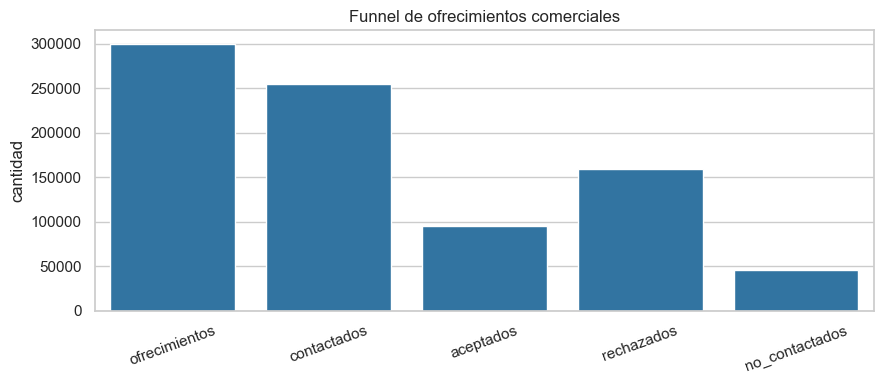

In [23]:
# Graficar el funnel comercial observado
plt.figure(figsize=(9, 4))
sns.barplot(data=funnel, x="etapa", y="cantidad", color="#1f77b4")
plt.title("Funnel de ofrecimientos comerciales")
plt.xlabel("")
plt.ylabel("cantidad")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Hallazgo de negocio:** de 300,112 ofrecimientos, 254,618 fueron contactados (84.84%) y 45,494 quedaron no contactados (15.16%). La aceptacion entre casos cerrados es 37.47%, mientras que la conversion sobre todos los intentos baja a 31.79%. Para la solucion conviene separar dos problemas: probabilidad de contacto y probabilidad de aceptacion condicionada a que exista contacto.

In [24]:
# Comparar contactabilidad y conversion por canal
campanias["contactado"] = (campanias["contactabilidad"] == "contactado").astype(int)
campanias["aceptada"] = (campanias["resultado"] == "aceptada").astype(int)

canal_funnel = campanias.groupby("canal").agg(
    ofrecimientos=("ofrecimiento_id", "size"),
    contactabilidad_pct=("contactado", "mean"),
    conversion_total_pct=("aceptada", "mean")
)
canal_funnel[["contactabilidad_pct", "conversion_total_pct"]] *= 100
canal_funnel.round(2)

,ofrecimientos,contactabilidad_pct,conversion_total_pct
canal,,,
call in,60065,84.94,31.68
call out,45264,84.81,31.76
digital,104598,84.84,31.77
tienda,90185,84.79,31.91


**Hallazgo de negocio:** la contactabilidad y la conversion total son casi iguales entre canales. El canal aporta contexto operativo, pero con estos datos no hay evidencia para declarar un canal ganador ni usarlo como regla principal de hiperpersonalizacion. Su valor podria aparecer al combinarlo con perfil, momento y oferta dentro del modelo.

In [25]:
# Verificar en que resultados aparece la accion de rebate
pd.crosstab(campanias["es_rebate"], campanias["resultado"], margins=True)

resultado,aceptada,pendiente,rechazada,All
es_rebate,,,,
False,95414,45494,111632,252540
True,0,0,47572,47572
All,95414,45494,159204,300112


**Hallazgo de negocio:** los 47,572 registros con `es_rebate = True` aparecen solamente como rechazados. Por tanto, este dataset indica que hubo un intento de contraoferta, pero no contiene un resultado posterior que permita medir si el rebate recupero la venta. `es_rebate` no debe entrar como predictor de aceptacion porque ocurre despues del rechazo. Para evaluar su efectividad se necesita registrar el resultado posterior al rebate.